# Analisis Tarifas Telefonicas

# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.


**1. Plan de acción**

El objetivo central del proyecto es analizar el comportamiento de los clientes para determinar qué tarifa de prepago es más popular o, mejor dicho, cuál resulta más rentable.

Para ello, determinaremos en qué aspectos se diferencian más, ya sea en el volumen de llamadas, mensajes, variaciones regionales, influencia del horario, entre otros factores.

Buscaremos responder a las siguientes interrogantes:

¿Es el paquete Ultimate, al ser el más costoso y ofrecer mayores beneficios, el que genera más ingresos?

¿O es el plan Surf el que genera mayor rentabilidad al ser más económico y captar a un mayor número de usuarios?

**Paso 1: Análisis de la estructura inicial de los datasets**

Comenzaremos analizando la estructura de los datos mediante los siguientes pasos:

- Carga de datos: Conversión a DataFrames utilizando la librería Pandas con el método read_csv().

- Estructura inicial: Inspección de los delimitadores y separadores para asegurar una lectura correcta de los archivos.

- Exploración de tipos: Uso del método info() para verificar los tipos de datos cargados y ejecución de sample(random_state=#) para obtener una muestra equilibrada y representativa.

- Coherencia de datos: Verificación de que los tipos de datos sean consistentes con la información que describen.

- Limpieza: Identificación y tratamiento de duplicados, así como la gestión de valores ausentes para garantizar la efectividad del análisis.

- Enriquecimiento: Evaluación de nuevas variables o información relevante que pueda agregarse a los datasets originales.

- Validación final: Correcciones de último minuto y comprobación de que no existan valores nulos residuales.

- Consolidación: Tras la limpieza, uniremos las tablas para centralizar los registros de los usuarios, permitiendo comparativas mensuales y la extracción de conclusiones sólidas.

**2. Análisis**

Una vez completada la limpieza y combinación de los datasets, agruparemos los registros de consumo (llamadas, mensajes y datos) de forma mensual para cada plan.

- Visualización: Se elaborarán gráficos de barras para obtener una comparativa visual de los consumos mensuales de cada plan en cuanto a mensajes, llamadas e internet. Asimismo, se crearán histogramas para analizar el tipo de distribución de los datos.

- Rentabilidad: Crearemos una comparativa de ingresos por plan, utilizando la tabla agrupada de todos los datasets, para descubrir cuál es el más rentable para la compañía.

**3.Pruebas de hipótesis**

Realizaremos dos pruebas estadísticas para validar nuestras conclusiones:

- Comparativa de Planes: Determinar si existe una diferencia significativa entre los ingresos del plan Ultimate (el más caro) y el plan Surf (el más económico), o si sus ingresos promedio se equiparan.

- Análisis Regional: Dado que la mayoría de los usuarios en la muestra pertenecen a una sola región, compararemos si los ingresos de dicha región predominante difieren de los ingresos promedio de las demás regiones.

## Inicialización

In [1]:
# Cargar todas las librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import numpy as np
from math import factorial


## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames

plans = pd.read_csv('/datasets/megaline_plans.csv')
users = pd.read_csv('/datasets/megaline_users.csv')
messages = pd.read_csv('/datasets/megaline_messages.csv')
calls = pd.read_csv('/datasets/megaline_calls.csv')
internet = pd.read_csv('/datasets/megaline_internet.csv')


## Preparar los datos

**Exploración de datos**

Comenzaremos por descubrir la estructura inicial de los datos. Esto incluye la revisión de:

Separadores: Verificar que los archivos se lean correctamente.

Nombres de columnas: Identificar el uso de mayúsculas innecesarias o la falta de formato snake_case.

Claridad: Corregir nombres poco claros o ambiguos.

Limpieza de cadenas: Detectar y eliminar espacios extra en los registros o encabezados.

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
display(plans.head()) # Se usa el metodo "head()" ya que detectamos gracias a Info que solo tenemos 2 filas por lo que "sample()" no seria relevante en este caso.


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


El dataset tiene una estructura de 8 columnas con 2 filas.

En general describe como se conforma cada paquete en los que estamos interesados, como:

- Limite de mensajes
- Limite de mb por mes
- Minutos para llamadas
- Costo de cada paquete
- Costos al exceder el limite del plan para cada rubro.
- Nombre del plan

No se observan datos ausentes ni nulos

Las columnas de mb_per_month_included es algo engañosa, ya que muestra el total de mb incluidos pero el cobro extra se hace por GB y realizar calculos posteriores con esta columna seria problematico ya que elevaria las cifras artificialmente.

Crearemos una columna nueva con estos valores pero convertidos a gb para que sea consistente con el cobro extra de gb consumido si se excede el plan, pero manteniendo la columna original para no perder la referencia inicial.


## Corregir datos

In [5]:
plans['gb_per_month'] = np.ceil(plans['mb_per_month_included'] / 1024).astype(int)

display(plans)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month
0,50,15360,500,20,10,0.03,0.03,surf,15
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30


## Enriquecer los datos

In [6]:
#crearemos una segunda columna en este dataset en el cual delimitaremos el costo tambien por mb extra dividiendo el precio por gb extra entre 1024 para tener este valor disponible tambien de manera informativa.

plans['usd_per_mb'] = plans['usd_per_gb']/1024

display(plans)


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month,usd_per_mb
0,50,15360,500,20,10,0.03,0.03,surf,15,0.009766
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30,0.006836


## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprime una muestra de datos para usuarios
display(users.sample(10,random_state=45))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
204,1204,Sherly,Levy,44,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-08-20,ultimate,NaN
481,1481,Roni,Frye,32,"Urban Honolulu, HI MSA",2018-12-27,surf,NaN
296,1296,Weston,Conley,36,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-10-20,ultimate,2018-12-18
38,1038,Olympia,Velazquez,32,"Nashville-Davidson–Murfreesboro–Franklin, TN MSA",2018-06-25,ultimate,NaN
298,1298,Loyce,Cooley,53,"Nashville-Davidson–Murfreesboro–Franklin, TN MSA",2018-09-21,surf,2018-12-19
61,1061,Maryam,Valencia,38,"Columbia, SC MSA",2018-03-08,ultimate,NaN
371,1371,Roderick,Slater,27,"Portland-Vancouver-Hillsboro, OR-WA MSA",2018-10-27,surf,NaN
360,1360,Arturo,Mullins,75,"Charlotte-Concord-Gastonia, NC-SC MSA",2018-09-20,surf,NaN
413,1413,Andre,Hensley,38,"Bakersfield, CA MSA",2018-07-12,surf,NaN
64,1064,Gerardo,Ashley,46,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-03,surf,NaN



**Análisis de la estructura del Dataset**

El dataset cuenta con una estructura de 8 columnas y 500 filas:

`reg_date`: Tiene un formato de `object` en lugar de `datetime`. Se debe establecer el formato de fecha `AAAA-MM-DD` para permitir agrupaciones correctas en análisis futuros.

`churn_date`: Según la documentación, si el valor es ausente, el servicio seguía activo al momento de extraer los datos. Si contiene una fecha (que actualmente es de tipo `object`), indica que el usuario ha cancelado el servicio. La columna presenta 34 datos no nulos, lo que significa que 34 usuarios de esta muestra ya habían cancelado o suspendido su suscripción.

Correcciones técnicas:
Procederemos a transformar las columnas `'churn_date'` y `'reg_date'` utilizando el método `to_datetime()` para establecer el formato de fecha correcto.


### Corregir los datos

In [9]:
#verificaremos primero si el Dataframe tiene Filas Duplicadas con la siguiente linea:
users_duplicates = users.duplicated().sum()

print(f"El Dataframe 'users' contiene {users_duplicates} duplicados.")


El Dataframe 'users' contiene 0 duplicados.


In [10]:
# Despues de verificar si existen duplicados se procede a la correccion de las fechas a formato de fecha correcto.
users['reg_date'] = pd.to_datetime(users['reg_date'], format='%Y-%m-%d')
users['churn_date']= pd.to_datetime(users['churn_date'], format='%Y-%m-%d')
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


Despues de ejecutar estas lineas confirmamos que las fechas se corrigieron satisfactoriamente y ahora son tipo `datetime64`

In [11]:
display(users.sample(10,random_state=45))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
204,1204,Sherly,Levy,44,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-08-20,ultimate,NaT
481,1481,Roni,Frye,32,"Urban Honolulu, HI MSA",2018-12-27,surf,NaT
296,1296,Weston,Conley,36,"Miami-Fort Lauderdale-West Palm Beach, FL MSA",2018-10-20,ultimate,2018-12-18
38,1038,Olympia,Velazquez,32,"Nashville-Davidson–Murfreesboro–Franklin, TN MSA",2018-06-25,ultimate,NaT
298,1298,Loyce,Cooley,53,"Nashville-Davidson–Murfreesboro–Franklin, TN MSA",2018-09-21,surf,2018-12-19
61,1061,Maryam,Valencia,38,"Columbia, SC MSA",2018-03-08,ultimate,NaT
371,1371,Roderick,Slater,27,"Portland-Vancouver-Hillsboro, OR-WA MSA",2018-10-27,surf,NaT
360,1360,Arturo,Mullins,75,"Charlotte-Concord-Gastonia, NC-SC MSA",2018-09-20,surf,NaT
413,1413,Andre,Hensley,38,"Bakersfield, CA MSA",2018-07-12,surf,NaT
64,1064,Gerardo,Ashley,46,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-03,surf,NaT


### Enriquecer los datos

Crearemos tres columnas nuevas para facilitar el filtrado de datos. Estas se generarán extrayendo información de las columnas originales, las cuales mantendremos intactas para no alterar la estructura inicial del dataset:

Columna `state`: Extraeremos el estado del usuario para permitir un análisis regional mediante filtros posteriores.

Columna de actividad: Clasificaremos a los usuarios de la columna `churn_dat`e. Asignaremos `1` a los usuarios con valores ausentes (quienes continúan activos) y `0` a los usuarios con valores no nulos (aquellos que ya cancelaron su servicio).

Columna `month`: Extraeremos el mes de la fecha de registro en `reg_date` para facilitar el filtrado y la agrupación de usuarios por periodos mensuales.



In [12]:
#Se crea la serie booleana de usuarios activos: 1 = Activos, 0 = Inactivos
users['is_active'] = users['churn_date'].isna().astype('int')
print(users['is_active'].value_counts())
print()
users_state = users['city'].str.split(',').str[1]

users['state'] = users_state.str.replace('MSA','',regex=False).str.strip()

print(users['state'].value_counts())

display(users[['city','state']].sample(10))

1    466
0     34
Name: is_active, dtype: int64

NY-NJ-PA       80
CA             78
TX             39
FL             25
IL-IN-WI       19
PA-NJ-DE-MD    17
MI             16
GA             14
WA             13
TN             12
MA-NH          12
MN-WI          11
AZ             11
DC-VA-MD-WV    11
CO              9
LA              9
OH              9
OH-KY-IN        8
OR-WA           8
NC-SC           8
SC              7
NV              7
OK              6
IN              6
NY              6
CT              6
PA              5
HI              5
KY-IN           5
MD              4
AL              4
VA-NC           4
VA              4
MO-IL           3
UT              3
WI              3
RI-MA           3
NM              2
MO-KS           2
NE-IA           2
NC              2
TN-MS-AR        2
Name: state, dtype: int64


,city,state
287,"Sacramento–Roseville–Folsom, CA MSA",CA
308,"Virginia Beach-Norfolk-Newport News, VA-NC MSA",VA-NC
13,"Knoxville, TN MSA",TN
447,"Orlando-Kissimmee-Sanford, FL MSA",FL
162,"Los Angeles-Long Beach-Anaheim, CA MSA",CA
3,"Tulsa, OK MSA",OK
160,"Portland-Vancouver-Hillsboro, OR-WA MSA",OR-WA
78,"Seattle-Tacoma-Bellevue, WA MSA",WA
280,"New York-Newark-Jersey City, NY-NJ-PA MSA",NY-NJ-PA
156,"Albuquerque, NM MSA",NM


In [13]:
# Se crea la columna 'reg_month' para la revision de la cantidad de registros por mes esto nos dara mas flexibilidad a ala hora de analizar a mas profundidad los datos por mes y la logevidad de los usuarios.

users['month'] = users['reg_date'].dt.month

reg_per_month = users['month'].value_counts().sort_index()

print("Cantidad de Registros Por Mes")
print(reg_per_month)

Cantidad de Registros Por Mes
1     49
2     42
3     40
4     45
5     38
6     54
7     36
8     47
9     32
10    42
11    38
12    37
Name: month, dtype: int64


In [14]:
#verificamos Todas las columnas creadas

display(users.sample(5,random_state=34))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_active,state,month
163,1163,Lanie,Washington,27,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-01-12,ultimate,NaT,1,CA,1
183,1183,Jermaine,Gallegos,71,"Chicago-Naperville-Elgin, IL-IN-WI MSA",2018-07-20,surf,NaT,1,IL-IN-WI,7
286,1286,Casie,Castaneda,52,"New Haven-Milford, CT MSA",2018-12-07,surf,NaT,1,CT,12
105,1105,Micheal,Poole,57,"Providence-Warwick, RI-MA MSA",2018-01-08,surf,NaT,1,RI-MA,1
436,1436,Jennine,Kinney,69,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",2018-08-26,ultimate,NaT,1,PA-NJ-DE-MD,8


## Llamadas

In [15]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


**Respuesta Estudiante:**


Se corrigio la variable dentro de info()

In [16]:
# Imprime una muestra de datos para las llamadas

calls_na = calls.isna().sum()
calls_duplicated = calls.duplicated().sum()

print(f"El numero de valores ausentes es de:")
print(calls_na)
print(f"El numero de registros duplicados es de: {calls_duplicated}")
print()
display(calls.sample(5,random_state=25))

El numero de valores ausentes es de:
id           0
user_id      0
call_date    0
duration     0
dtype: int64
El numero de registros duplicados es de: 0



,id,user_id,call_date,duration
59445,1214_514,1214,2018-04-12,1.87
34514,1130_34,1130,2018-11-12,0.00
54329,1196_212,1196,2018-10-31,9.29
132025,1475_172,1475,2018-09-10,0.00
16217,1064_75,1064,2018-10-27,2.79



**Análisis de la estructura del Dataset de llamadas**

El dataset cuenta con una estructura de 4 columnas y 137735 filas de registro.

Formato de fechas: A primera vista, se observa que la columna `call_date` no tiene el formato de fecha adecuado. Se debe corregir para permitir el filtrado temporal y detectar patrones de consumo.

Valores ausentes: Aparentemente no se observan datos ausentes; sin embargo, ejecutaremos `isna().sum()` para verificarlo con precisión.

Duplicados: Comprobaremos la existencia de registros duplicados utilizando directamente el método `duplicated()` sobre el DataFrame.

Redondeo de consumo: Según la documentación, la compañía redondea hacia arriba las fracciones de minuto (por ejemplo, `1.49` pasa a `2`). Crearemos una columna nueva para estos valores redondeados, manteniendo la original intacta por referencia. Para esto, utilizaremos la función `ceil()`, cumpliendo así con las políticas de facturación de la compañía.

Llamadas de duración `0.0`: Identificamos un volumen considerable de llamadas con duración de `0.0`. Esto podría indicar llamadas no contestadas o perdidas; por lo tanto, las aislaremos en una variable diferente para mantenerlas bajo observación sin que afecten los cálculos de consumo promedio.


### Corregir los datos

In [17]:
# Realizamos el cambio de formato de tipo objet en la columna "call_date" para que sea un formato de fecha correcto.

calls['call_date'] = pd.to_datetime(calls['call_date'],format=  '%Y-%m-%d')

calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


### Enriquecer los datos

Se creará una columna `call_month` en la cual extraeremos el mes de las llamadas realizadas. Esto nos permitirá filtrar a través del tiempo para establecer patrones en las llamadas de una manera eficaz.


In [18]:
calls['month'] = calls['call_date'].dt.month

calls_per_month = calls['month'].value_counts().sort_index()

print("Cantidad de llamadas Por Mes")
print(calls_per_month)

Cantidad de llamadas Por Mes
1       172
2       774
3      1620
4      3442
5      5959
6      8221
7     11105
8     13590
9     16523
10    21064
11    24651
12    30614
Name: month, dtype: int64


Observacion:

Se observa un Claro incremento de llamadas a mediados del año, ¿Tendra que ver con las Fechas de Registro de los usuarios?.

In [19]:
# Redondeamos las llamadas de la columna original "duration" al entero siguiente para cumplir con la politica de la compañia.

calls['calls_duration_mins'] = np.ceil(calls['duration']).astype(int)

# Extraemos las llamadas con duracion 0 para almacenarlas en una variable independiente y poder determinar el porcentaje de estas llamadas dentro del Dataframe original.

zero_calls_duration = calls[calls['duration'] == 0]

print(f"Porcentaje de llamadas perdidas: {len(zero_calls_duration) / len(calls):.2%}")

display(calls.sample(10,random_state=15))

Porcentaje de llamadas perdidas: 19.48%


,id,user_id,call_date,duration,month,calls_duration_mins
26617,1100_174,1100,2018-11-28,7.66,11,8
88146,1324_192,1324,2018-12-15,8.04,12,9
62381,1223_567,1223,2018-07-16,5.59,7,6
77619,1277_695,1277,2018-07-21,10.19,7,11
62892,1226_291,1226,2018-12-10,14.57,12,15
55981,1201_79,1201,2018-08-09,5.73,8,6
99926,1358_323,1358,2018-10-30,5.43,10,6
48990,1176_89,1176,2018-10-25,14.15,10,15
32883,1123_241,1123,2018-11-13,9.49,11,10
107688,1382_419,1382,2018-10-24,0.00,10,0


Tenemos un 19.48 % de llamadas no contestadas o perdidas dentro de todo el Dataset.

## Mensajes

In [20]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes

print("El número de valores ausentes es:")
print(messages.isna().sum())
print()
print(f"El número de registros duplicados es de: {messages.duplicated().sum()}")

messages.info()


El número de valores ausentes es:
id              0
user_id         0
message_date    0
dtype: int64

El número de registros duplicados es de: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


**Respuesta Estudiante:**

El proyecto pide este paso que suguiere en la celda siguiente, como esta echo en la celda siguiente.

In [21]:
# Imprime una muestra de datos para los mensajes

display(messages.sample(10,random_state=16))

,id,user_id,message_date
12284,1081_23,1081,2018-06-07
52743,1336_778,1336,2018-04-23
54357,1343_457,1343,2018-12-13
41729,1268_102,1268,2018-10-08
18582,1120_429,1120,2018-05-23
12623,1082_174,1082,2018-11-28
50790,1330_425,1330,2018-12-19
63198,1401_157,1401,2018-10-26
2314,1028_223,1028,2018-12-27
4813,1045_15,1045,2018-11-01



En este dataset no se observan valores nulos ni registros duplicados.

Formato de fechas: Al igual que en los datasets anteriores, la columna de fecha no cuenta con el formato correcto. Realizaremos la conversión necesaria para estandarizar los datos.

Agrupación temporal: Crearemos la columna message_month a partir de la fecha de envío. Esto nos permitirá filtrar los mensajes y agruparlos por mes para facilitar el análisis de patrones de uso.


### Corregir los datos

Corregiremos los formatos de fecha, tal como realizamos anteriormente, utilizando el método `to_datetime()` para establecer el valor adecuado para el análisis posterior.

In [22]:
messages['message_date'] = pd.to_datetime(messages['message_date'], format='%Y-%m-%d')

messages.info()
display(messages.sample(5,random_state=18))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


,id,user_id,message_date
18906,1122_135,1122,2018-05-27
72658,1470_286,1470,2018-08-08
9446,1069_472,1069,2018-11-12
24741,1146_494,1146,2018-12-19
68742,1444_225,1444,2018-09-05


Se corrige satisfactoriamente el formato de la fecha en el Dataframe.

### Enriquecer los datos

Crearemos la Columna de mensajes mensuales que nos ayudara en analisis posteriores extrayendo el mes.


In [23]:
messages['month'] = messages['message_date'].dt.month

display(messages.sample(5,random_state=18))

,id,user_id,message_date,month
18906,1122_135,1122,2018-05-27,5
72658,1470_286,1470,2018-08-08,8
9446,1069_472,1069,2018-11-12,11
24741,1146_494,1146,2018-12-19,12
68742,1444_225,1444,2018-09-05,9


## Internet

In [24]:
# Imprime la información general/resumida sobre el DataFrame de internet
print("EL numero de valores nulos es:")
print(internet.isna().sum())
print()
print(f"El número de Valores Duplicados es de: {internet.duplicated().sum()}")
print()
internet.info()

EL numero de valores nulos es:
id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

El número de Valores Duplicados es de: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [25]:
# Imprime una muestra de datos para el tráfico de internet

display(internet.sample(10,random_state=38))


,id,user_id,session_date,mb_used
42912,1191_91,1191,2018-05-04,857.18
35279,1159_116,1159,2018-11-24,709.86
55132,1249_415,1249,2018-06-20,291.43
74965,1353_128,1353,2018-06-28,104.58
39803,1179_134,1179,2018-12-27,158.57
55722,1252_134,1252,2018-08-27,525.67
37540,1170_339,1170,2018-11-09,0.00
16462,1073_401,1073,2018-09-04,221.43
9209,1047_47,1047,2018-12-26,407.50
192,1001_345,1001,2018-08-18,249.51



Análisis del dataset de internet

No se observan valores nulos, ausentes ni registros duplicados en este dataset.

Formato de fechas: La columna de fecha se encuentra en formato `object`, al igual que en los demás DataFrames. Utilizaremos el mismo método, `to_datetime()`, para convertirla al formato correcto.

Política de redondeo: Según la documentación, las sesiones individuales no se redondean. Por lo tanto, pospondremos la agrupación para un paso posterior y mantendremos la información de los `mb` tal como se encuentra originalmente.

Gestión de sesiones en `0.0`: Crearemos una columna para identificar las sesiones con valor de `0.0`. Esto nos permitirá realizar consultas específicas posteriormente sin necesidad de eliminar esta información por el momento.



### Corregir los datos

Al igual que en los datasets anteriores, convertiremos las fechas en formato correcto con el mismo metodo para poder realizar el filtro en el siquiente paso.

In [26]:
# Convertimos la Fecha Satisfactoriamente al formato correcto.

internet['session_date'] = pd.to_datetime(internet['session_date'],format='%Y-%m-%d')

sessions_empty = internet[internet['mb_used'] == 0]

display(internet.sample(5,random_state=25))
print()
# Mostramos la información nuevamente del DF para verificar el cambio de tipo object a datetime64
internet.info()

,id,user_id,session_date,mb_used
4706,1028_265,1028,2018-09-19,205.11
39181,1176_2,1176,2018-12-10,165.55
74526,1351_12,1351,2018-12-20,132.41
54938,1249_131,1249,2018-08-22,504.56
7667,1041_507,1041,2018-10-05,0.00



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriquecer los datos

Crearemos una columna `month` para facilitar la agrupación mensual. Esto nos permitirá sumar las sesiones de los usuarios, calcular el total de `mb` consumidos y determinar el consumo final en `gb` por cada mes.


In [27]:
internet['month'] = internet['session_date'].dt.month

sessions_empty = internet[internet['mb_used'] == 0]
print(f"Sesiones con 0 mb: {len(sessions_empty)} ")
print()
print(f"Total de Sesiones del DF: {len(internet)}")
print()
print(f"Porcentaje de sesiones con 0 mb: {len(sessions_empty)/len(internet):.2%} ")

Sesiones con 0 mb: 13747 

Total de Sesiones del DF: 104825

Porcentaje de sesiones con 0 mb: 13.11% 


## Estudiar las condiciones de las tarifas

Imprimiremos nuevamente los datos de las tarifas de cada plan para sus respectivos consumos. Esto nos permitirá realizar las operaciones exactas de acuerdo con la política de facturación de la compañía para el cálculo del cobro mensual.

In [28]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

display(plans)

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month,usd_per_mb
0,50,15360,500,20,10,0.03,0.03,surf,15,0.009766
1,1000,30720,3000,70,7,0.01,0.01,ultimate,30,0.006836


## Agregar datos por usuario


In [29]:
calls.columns

Index(['id', 'user_id', 'call_date', 'duration', 'month',
       'calls_duration_mins'],
      dtype='object')

In [30]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.

calls_per_month = calls.groupby(['user_id', 'month'])['id'].count().reset_index()

In [31]:
display(calls_per_month.head())

,user_id,month,id
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [32]:
calls_per_month.columns = ['user_id','month','calls_made']

display(calls_per_month.head())

,user_id,month,calls_made
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [33]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
calls['duration_rounded'] = np.ceil(calls['duration'])

mins_per_month = calls.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index()

# mins_per_month['duration'] = np.ceil(mins_per_month['duration'])

display(mins_per_month.head())

,user_id,month,duration_rounded
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0


**Respuesta:**
Se corrigio el error del redondeo depues de la agrupacion de la siguiente manera:

Codigo Inicial:

`mins_per_month = calls.groupby(['user_id', 'month'])['duration'].sum().reset_index()`

`mins_per_month['duration'] = np.ceil(mins_per_month['duration'])`

Codigo Corregido:

`calls['duration_rounded'] = np.ceil(calls['duration'])`

`mins_per_month = calls.groupby(['user_id', 'month'])['duration_rounded'].sum().reset_index()`

In [34]:
mins_per_month.columns = ['user_id','month','minutes_spent']
display(mins_per_month.head())

,user_id,month,minutes_spent
0,1000,12,124.0
1,1001,8,182.0
2,1001,9,315.0
3,1001,10,393.0
4,1001,11,426.0


In [35]:
messages.columns

Index(['id', 'user_id', 'message_date', 'month'], dtype='object')

In [36]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.

msg_per_month = messages.groupby(['user_id','month'])['id'].count().reset_index()
msg_per_month.columns = ['user_id','month','msg_count']
display(msg_per_month.head())

,user_id,month,msg_count
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [37]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
int_per_month = internet.groupby(['user_id','month'])['mb_used'].sum().reset_index()
int_per_month.columns = ['user_id','month','mb_total']
int_per_month['gb_used'] = np.ceil(int_per_month['mb_total']/1024)
display(int_per_month.head())

,user_id,month,mb_total,gb_used
0,1000,12,1901.47,2.0
1,1001,8,6919.15,7.0
2,1001,9,13314.82,14.0
3,1001,10,22330.49,22.0
4,1001,11,18504.30,19.0


Gracias a la creación de la columna `month` en cada dataset, podemos realizar la unión basándonos en los identificadores de usuario y mes. Esto nos permite agregar el resto de las columnas de consumo y consolidar toda la información en una sola tabla, facilitando así el filtrado ordenado y el almacenamiento de los datos individuales por usuario.

In [38]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

meg_merged = calls_per_month.merge(mins_per_month, on=['user_id','month'],how='outer')
display(meg_merged.head())
meg_merged = meg_merged.merge(msg_per_month,on=['user_id','month'],how='outer')
display(meg_merged.head())
meg_merged = meg_merged.merge(int_per_month,on=['user_id','month'],how='outer')
display(meg_merged.head())

,user_id,month,calls_made,minutes_spent
0,1000,12,16,124.0
1,1001,8,27,182.0
2,1001,9,49,315.0
3,1001,10,65,393.0
4,1001,11,64,426.0


,user_id,month,calls_made,minutes_spent,msg_count
0,1000,12,16.0,124.0,11.0
1,1001,8,27.0,182.0,30.0
2,1001,9,49.0,315.0,44.0
3,1001,10,65.0,393.0,53.0
4,1001,11,64.0,426.0,36.0


,user_id,month,calls_made,minutes_spent,msg_count,mb_total,gb_used
0,1000,12,16.0,124.0,11.0,1901.47,2.0
1,1001,8,27.0,182.0,30.0,6919.15,7.0
2,1001,9,49.0,315.0,44.0,13314.82,14.0
3,1001,10,65.0,393.0,53.0,22330.49,22.0
4,1001,11,64.0,426.0,36.0,18504.30,19.0


In [39]:
# Añade la información de la tarifa

final_meg_merged = meg_merged.merge(users[['user_id','plan','city','state']],on='user_id',how='left')

final_meg_merged = final_meg_merged.merge(plans, left_on='plan',right_on='plan_name', how='left')

display(final_meg_merged.head(2))

print(final_meg_merged.info())

# al hacer la union de los Datatasets combinados con el de las tarifas, se nos duplica de cierto modo la columna del nombre del plan por lo que es irrelevante tener 2 del mismo tipo y optamos por eliminar la columna de 'plan_name'.

final_meg_merged = final_meg_merged.drop(columns=['plan_name'])

print()

display(final_meg_merged.sample(10,random_state=45))

#f verificamos si despues de la creacion del dataframe conbinado tenemos  nuevamente valores nulos.

print(final_meg_merged.isna().sum())


,user_id,month,calls_made,minutes_spent,msg_count,mb_total,gb_used,plan,city,state,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name,gb_per_month,usd_per_mb
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",GA,1000,30720,3000,70,7,0.01,0.01,ultimate,30,0.006836
1,1001,8,27.0,182.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",WA,50,15360,500,20,10,0.03,0.03,surf,15,0.009766


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2293 non-null   int64  
 1   month                  2293 non-null   int64  
 2   calls_made             2258 non-null   float64
 3   minutes_spent          2258 non-null   float64
 4   msg_count              1806 non-null   float64
 5   mb_total               2277 non-null   float64
 6   gb_used                2277 non-null   float64
 7   plan                   2293 non-null   object 
 8   city                   2293 non-null   object 
 9   state                  2293 non-null   object 
 10  messages_included      2293 non-null   int64  
 11  mb_per_month_included  2293 non-null   int64  
 12  minutes_included       2293 non-null   int64  
 13  usd_monthly_pay        2293 non-null   int64  
 14  usd_per_gb             2293 non-null   int64  
 15  usd_

,user_id,month,calls_made,minutes_spent,msg_count,mb_total,gb_used,plan,city,state,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month,usd_per_mb
2045,1448,12,35.0,228.0,59.0,12864.80,13.0,surf,"Urban Honolulu, HI MSA",HI,50,15360,500,20,10,0.03,0.03,15,0.009766
145,1041,3,4.0,23.0,NaN,1586.39,2.0,ultimate,"Las Vegas-Henderson-Paradise, NV MSA",NV,1000,30720,3000,70,7,0.01,0.01,30,0.006836
1966,1429,12,21.0,130.0,17.0,6770.01,7.0,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",NY-NJ-PA,50,15360,500,20,10,0.03,0.03,15,0.009766
626,1136,11,64.0,507.0,42.0,21273.99,21.0,surf,"Knoxville, TN MSA",TN,50,15360,500,20,10,0.03,0.03,15,0.009766
1398,1312,5,60.0,368.0,27.0,22079.41,22.0,surf,"Fresno, CA MSA",CA,50,15360,500,20,10,0.03,0.03,15,0.009766
575,1123,12,87.0,716.0,38.0,24982.22,25.0,surf,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",PA-NJ-DE-MD,50,15360,500,20,10,0.03,0.03,15,0.009766
1026,1221,12,20.0,108.0,11.0,7904.00,8.0,surf,"Boston-Cambridge-Newton, MA-NH MSA",MA-NH,50,15360,500,20,10,0.03,0.03,15,0.009766
1970,1431,12,99.0,670.0,39.0,23992.00,24.0,surf,"Sacramento–Roseville–Folsom, CA MSA",CA,50,15360,500,20,10,0.03,0.03,15,0.009766
750,1160,9,89.0,680.0,23.0,15166.30,15.0,surf,"Portland-Vancouver-Hillsboro, OR-WA MSA",OR-WA,50,15360,500,20,10,0.03,0.03,15,0.009766
2226,1493,12,65.0,473.0,NaN,15289.09,15.0,ultimate,"Boston-Cambridge-Newton, MA-NH MSA",MA-NH,1000,30720,3000,70,7,0.01,0.01,30,0.006836


user_id                    0
month                      0
calls_made                35
minutes_spent             35
msg_count                487
mb_total                  16
gb_used                   16
plan                       0
city                       0
state                      0
messages_included          0
mb_per_month_included      0
minutes_included           0
usd_monthly_pay            0
usd_per_gb                 0
usd_per_message            0
usd_per_minute             0
gb_per_month               0
usd_per_mb                 0
dtype: int64


Tras identificar los valores ausentes y examinar las columnas correspondientes, verificamos que no se tratan de datos categóricos. Por lo tanto, decidimos rellenarlos con 0, dado que indican la ausencia de consumo excedente. El 0 es la opción más adecuada para realizar correctamente los cálculos posteriores de consumo total e ingresos.

In [40]:
print(final_meg_merged['user_id'].nunique()) # verificamos el Total de los usuarios dentro del dataset combinado.

# Al parecer perdimos 10 valores, qu epueden ser de los usuarios que no estan activos. 
print()

# Contamos los Valores ausentes en el dataset combinado

print(final_meg_merged.isna().sum())

final_meg_merged.fillna(0,inplace=True)

final_meg_merged.info()


490

user_id                    0
month                      0
calls_made                35
minutes_spent             35
msg_count                487
mb_total                  16
gb_used                   16
plan                       0
city                       0
state                      0
messages_included          0
mb_per_month_included      0
minutes_included           0
usd_monthly_pay            0
usd_per_gb                 0
usd_per_message            0
usd_per_minute             0
gb_per_month               0
usd_per_mb                 0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2293 entries, 0 to 2292
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2293 non-null   int64  
 1   month                  2293 non-null   int64  
 2   calls_made             2293 non-null   float64
 3   minutes_spent          2293 non-null   float64
 4   msg_cou


Rellenamos con exito los Valores NAN por 0 para el analisis de comportamiento de los usuarios.

In [41]:

# Calcula el ingreso mensual para cada usuario

mins_dif = final_meg_merged['minutes_spent']-final_meg_merged['minutes_included']
extra_mins = np.maximum(0,mins_dif)
mins_cost = extra_mins * final_meg_merged['usd_per_minute']

# se crean las variables de los costos totales de los consumos de los minutos (llamadas) solo si estos exceden el limite mensual de cada plan conntratado.

msg_dif = final_meg_merged['msg_count']-final_meg_merged['messages_included']
extra_msg = np.maximum(0,msg_dif)
msg_cost = extra_msg * final_meg_merged['usd_per_message']

# se crean las variables de los costos totales de los consumos de los mensajes solo si estos exceden el limite mensual de cada plan conntratado.

gb_dif = final_meg_merged['gb_used']-final_meg_merged['gb_per_month']
extra_gb = np.maximum(0,gb_dif)
gb_cost = extra_gb * final_meg_merged['usd_per_gb']

# se crean las variables de los costos totales de los consumos de internet solo si estos exceden el limite mensual de cada plan conntratado.

final_meg_merged['total_revenue'] = (final_meg_merged['usd_monthly_pay']+ mins_cost + msg_cost + gb_cost)

# Combinamos todos estos resultados de los consumos excedentes mas el costo original del plan para determinar que usuarios excediaron su plan y de haberlo hecho cual es el monto que deben pagar en base a sus excedidos para juntar todo en una columna de total de ingresos.

total_revenue_meg = final_meg_merged[['user_id', 'month', 'plan', 'total_revenue']]

display(total_revenue_meg.sample(5,random_state=58))
print()
print(total_revenue_meg.isna().sum()) # no presentamos valores ausentes lo cual es un idicatibo de que se realizo con exito la operacion de conversion de unidades y de suma total.


,user_id,month,plan,total_revenue
1691,1370,9,ultimate,70.0
1255,1270,11,ultimate,70.0
242,1056,9,surf,30.0
1954,1426,12,ultimate,70.0
77,1022,7,surf,20.0



user_id          0
month            0
plan             0
total_revenue    0
dtype: int64


**Respuesta**

Ya se corrigio el redondeode `minutes_spent` por consecuente debe estar corregida esta seccion.

## Estudia el comportamiento de usuario

### Llamadas

In [42]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

display(final_meg_merged['month'].head())

calls_per_month = final_meg_merged.groupby(['month','plan'])['minutes_spent'].mean().unstack()


0    12
1     8
2     9
3    10
4    11
Name: month, dtype: int64

plan         surf    ultimate
count   12.000000   12.000000
mean   384.469691  387.999742
std     76.535567   77.266064
min    203.000000  193.500000
25%    346.155000  362.432371
50%    412.168958  413.839000
75%    430.122211  439.432934
max    473.836478  459.099338


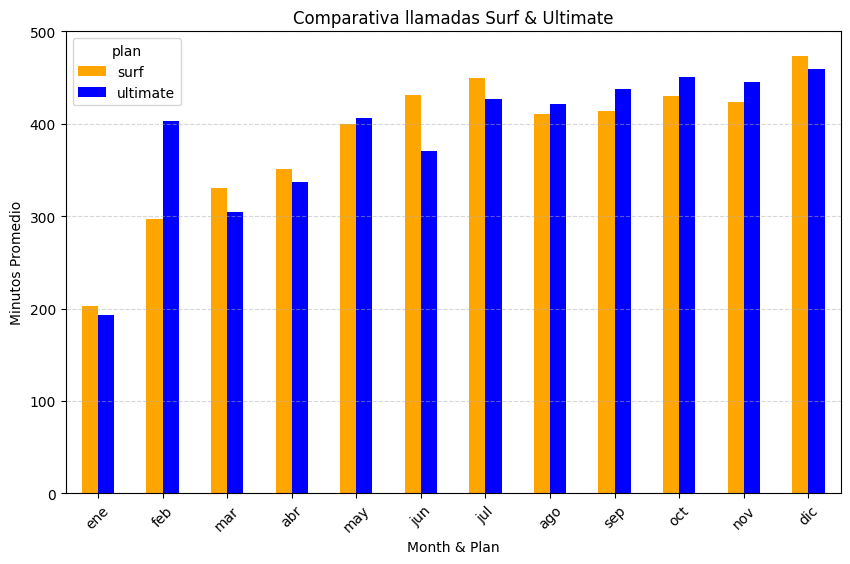

In [43]:
print(calls_per_month.describe())

max_idx= calls_per_month.idxmax()
max_value = calls_per_month.max()

months = {0:'ene',1:'feb',2:'mar',3:'abr',4:'may',5:'jun',6:'jul',7:'ago',8:'sep',9:'oct',10:'nov',11:'dic'}

calls_graph = calls_per_month.plot(kind='bar',
                                        xlabel='Month & Plan', ylabel='Minutos Promedio'
                                        ,color=['orange','blue'], rot=45,
                                        legend=True,
                                        title='Comparativa llamadas Surf & Ultimate',
                                        figsize=(10,6),
                                        ylim=(0,500)
                                        )
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(list(months.keys()),list(months.values()))

plt.show()


Se observa un patrón bastante similar entre los dos planes a lo largo del año. Aunque el plan `ultimate` muestra picos ligeramente más altos en algunos meses, ambos tienen una tendencia clara a incrementar el consumo conforme pasa el tiempo y se acercan las fechas navideñas.

Picos estacionales:

Diciembre: Es, sin duda, el mes con mayor consumo, lo cual está directamente relacionado con las celebraciones de fin de año.

Febrero: También notamos un repunte importante. Es muy probable que se deba a la influencia del 14 de febrero (San Valentín), fecha en la que aumenta el uso de llamadas y mensajes.


# Observaciones:


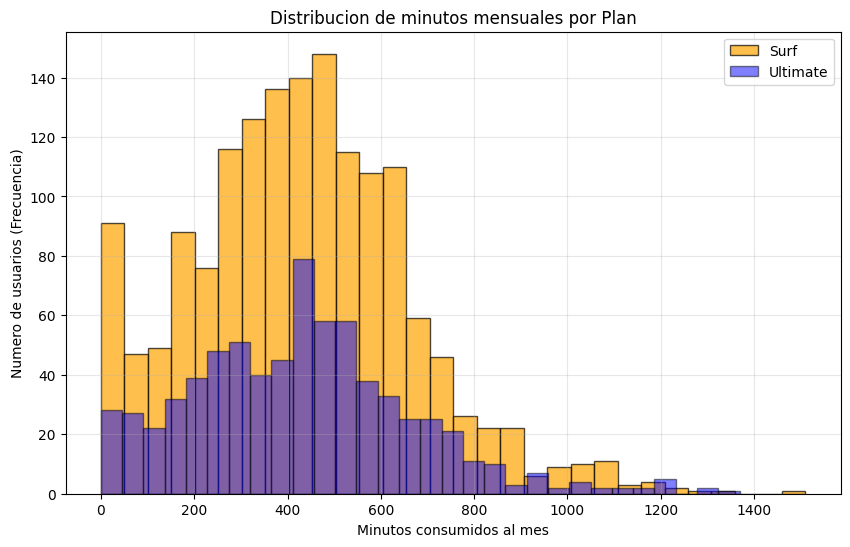


El número total de registros es: 2293
El número total de registros del plan 'surf' es: 1573, lo que equivale a un: 69 %
El número total de registros del plan 'ultimate' es: 720 lo que equivale a un: 31 %


In [44]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.



surf_minutes = final_meg_merged[final_meg_merged['plan']=='surf']['minutes_spent']
ultimate_minutes = final_meg_merged[final_meg_merged['plan']=='ultimate']['minutes_spent']

users_total = len(final_meg_merged)
surf_users = len(surf_minutes)
ultimate_users = len(ultimate_minutes)

plt.figure(figsize=(10,6))
plt.hist(surf_minutes, bins=30, alpha=0.7, label='Surf', color='orange', edgecolor='black')
plt.hist(ultimate_minutes, bins=30, alpha=0.5, label='Ultimate', color='blue',edgecolor='black')

plt.legend(loc='upper right')
plt.xlabel('Minutos consumidos al mes')
plt.ylabel('Numero de usuarios (Frecuencia)')
plt.title('Distribucion de minutos mensuales por Plan')
plt.grid(True, alpha=0.3)
plt.show()

print()
print(f"El número total de registros es: {users_total}")
print(f"El número total de registros del plan 'surf' es: {surf_users}, lo que equivale a un: {((surf_users/users_total)*100):.0f} %")
print(f"El número total de registros del plan 'ultimate' es: {ultimate_users} lo que equivale a un: {((ultimate_users/users_total)*100):.0f} %")

Al observar la distribución, parece seguir una tendencia normal, aunque con un sesgo hacia la derecha (sesgo positivo). Esto significa que, aunque la mayoría de los datos se concentran alrededor de la media, existen algunos valores atípicos o usuarios con consumos significativamente más altos que desplazan la curva.

Observaciones:
La mayor parte de los usuarios mantienen un gasto estable cercano al promedio, lo cual es típico en este tipo de servicios donde la renta básica fija marca el comportamiento principal de la mayoría del grupo.

In [45]:
# Calcula la media y la varianza de la duración mensual de llamadas.

df_surf = final_meg_merged[final_meg_merged['plan'] == 'surf']
df_ultimate = final_meg_merged[final_meg_merged['plan'] == 'ultimate']

surf_mean = df_surf['minutes_spent'].mean()
ultimate_mean = df_ultimate['minutes_spent'].mean()

var_surf = df_surf['minutes_spent'].var()
var_ultimate = df_ultimate['minutes_spent'].var()

surf_std = df_surf['minutes_spent'].std()
ultimate_std = df_ultimate['minutes_spent'].std()

print(f"Plan Surf - Media: {surf_mean:.2f}, Varianza: {var_surf:.2f}, Desviación estndar: {surf_std:.2f}")
print(f"Plan Ultimate - Media: {ultimate_mean:.2f}, Varianza: {var_ultimate:.2f}, Desviación estndar: {ultimate_std:.2f}")
print()
print("Plan Surf:")
print(f"Mínimo: {df_surf['minutes_spent'].min()}")
print(f"Máximo: {df_surf['minutes_spent'].max()}")
print("\nPlan Ultimate:")
print(f"Mínimo: {df_ultimate['minutes_spent'].min()}")
print(f"Máximo: {df_ultimate['minutes_spent'].max()}")

Plan Surf - Media: 428.75, Varianza: 54968.28, Desviación estndar: 234.45
Plan Ultimate - Media: 430.45, Varianza: 57844.46, Desviación estndar: 240.51

Plan Surf:
Mínimo: 0.0
Máximo: 1510.0

Plan Ultimate:
Mínimo: 0.0
Máximo: 1369.0


Al observar que la media y la varianza son muy próximas entre ambos planes, notamos una similitud importante en el comportamiento de los usuarios. Si bien esto sugiere que los planes tienen distribuciones comparables, para afirmar que son realmente normales, deberíamos apoyarnos en los histogramas o en pruebas estadísticas (como Shapiro-Wilk). Aun así, es claro que la mayoría de los usuarios de ambos planes se agrupan en rangos de consumo similares.

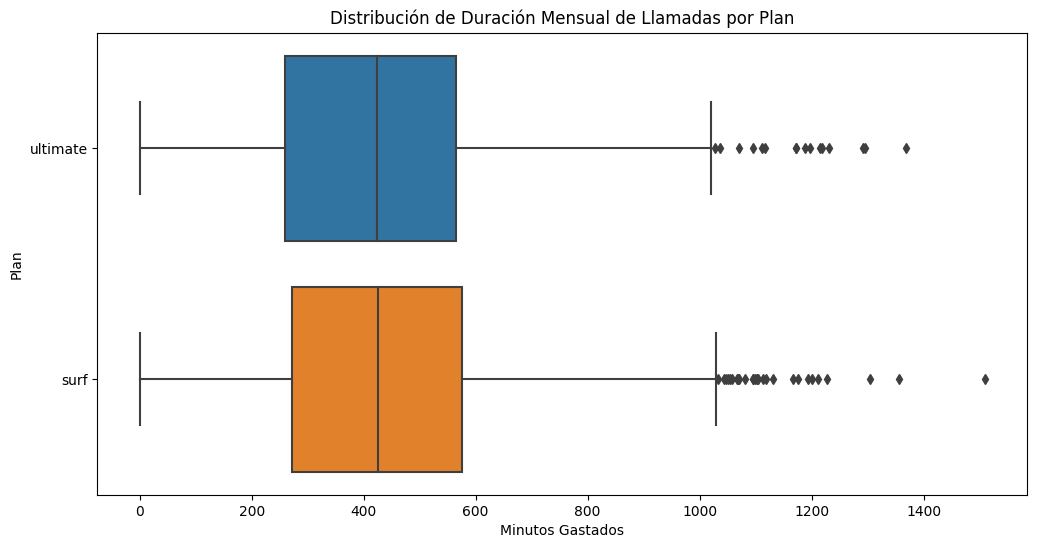

In [46]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(12,6))
sns.boxplot(data=final_meg_merged, y='plan', x='minutes_spent')
plt.title('Distribución de Duración Mensual de Llamadas por Plan')
plt.ylabel('Plan')
plt.xlabel('Minutos Gastados')
plt.show()

**Respuesta:**

Se corrigio la etiqueta de los ejes `x` y `y` por que anteriormente se habia generado de forma vertical el `boxplot` y olvide corregirlo.


Conclusiones:

Tras analizar el comportamiento de los usuarios, podemos destacar los siguientes puntos:

Patrones de consumo: Los usuarios de ambos planes muestran un comportamiento muy similar en cuanto a llamadas, con incrementos notables conforme se acercan las fechas festivas o periodos vacacionales.

Comportamiento del Plan Surf: Aunque el plan surf tiene un mayor volumen de registros, observamos una cantidad considerable de valores atípicos (outliers). Esto indica que hay un segmento de usuarios que supera ampliamente los límites incluidos en su plan.

Impacto en los ingresos: Esta tendencia es positiva para la compañía, ya que confirma que, incluso en el plan más económico, existe un margen de ingresos extra derivado de los excedentes en el consumo de los usuarios.

### Mensajes

In [47]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

user_msg_per_month = msg_per_month.merge(users[['user_id','plan']],on='user_id',how='left')

display(user_msg_per_month.head(2))

user_msg_plan = user_msg_per_month.groupby(['month','plan'])['msg_count'].mean().unstack()


display(user_msg_plan.head(5))
print(user_msg_plan.describe())


,user_id,month,msg_count,plan
0,1000,12,11,ultimate
1,1001,8,30,surf


plan,surf,ultimate
month,,
1,21.000000,20.666667
2,21.600000,25.166667
3,21.937500,34.714286
4,24.166667,28.937500
5,33.017857,44.333333


plan        surf   ultimate
count  12.000000  12.000000
mean   33.309767  39.472325
std     9.179563  10.327408
min    21.000000  20.666667
25%    23.609375  33.270089
50%    34.780747  42.773050
75%    39.780658  47.133632
max    48.326772  53.936508


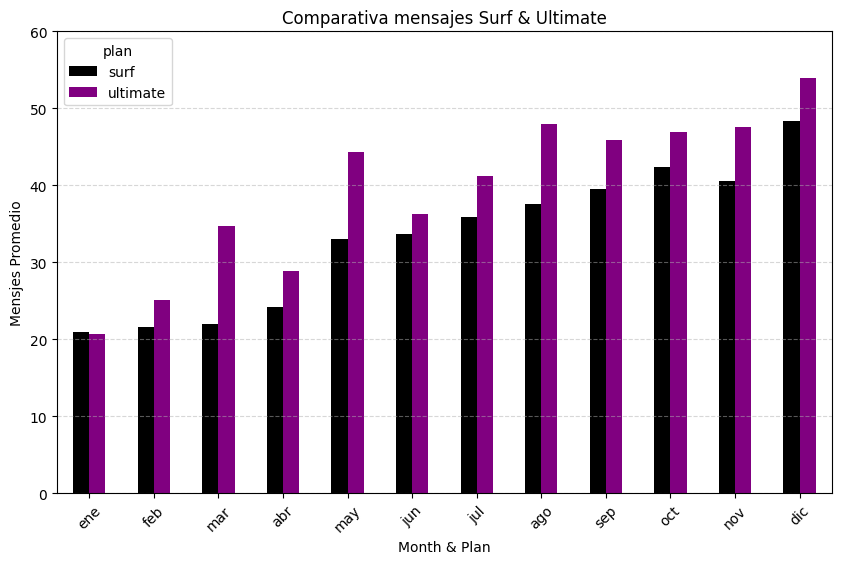

In [48]:
# Compara la cantidad de tráfico de mensjes consumidos por usuarios por plan

msg_graph_2 = user_msg_plan.plot(kind='bar',
                                        xlabel='Month & Plan', ylabel='Mensjes Promedio'
                                        ,color=['black','purple'], rot=45,
                                        legend=True,
                                        title='Comparativa mensajes Surf & Ultimate',
                                        figsize=(10,6),
                                        ylim=(0,60)
                                        )
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(list(months.keys()),list(months.values()))

plt.show()


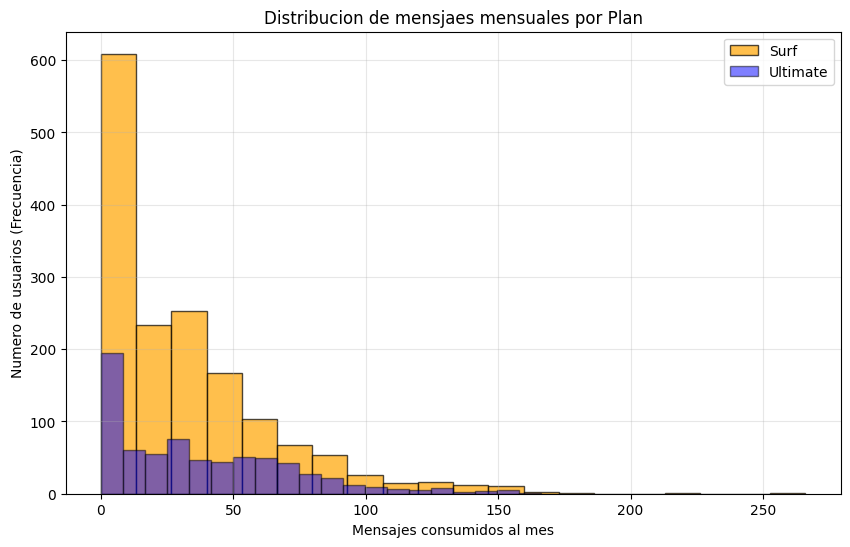


El número total de registros es: 2293
El número total de registros del plan 'surf' es: 1573, lo que equivale a un: 69 %
El número total de registros del plan 'ultimate' es: 720 lo que equivale a un: 31 %


In [49]:


surf_msg = final_meg_merged[final_meg_merged['plan']=='surf']['msg_count']
ultimate_msg = final_meg_merged[final_meg_merged['plan']=='ultimate']['msg_count']

plt.figure(figsize=(10,6))
plt.hist(surf_msg, bins=20, alpha=0.7, label='Surf', color='orange', edgecolor='black')
plt.hist(ultimate_msg, bins=20, alpha=0.5, label='Ultimate', color='blue',edgecolor='black')

plt.legend(loc='upper right')
plt.xlabel('Mensajes consumidos al mes')
plt.ylabel('Numero de usuarios (Frecuencia)')
plt.title('Distribucion de mensjaes mensuales por Plan')
plt.grid(True, alpha=0.3)
plt.show()

print()
print(f"El número total de registros es: {users_total}")
print(f"El número total de registros del plan 'surf' es: {surf_users}, lo que equivale a un: {((surf_users/users_total)*100):.0f} %")
print(f"El número total de registros del plan 'ultimate' es: {ultimate_users} lo que equivale a un: {((ultimate_users/users_total)*100):.0f} %")


In [50]:
surf_msg_mean = df_surf['msg_count'].mean()
ultimate_msg_mean = df_ultimate['msg_count'].mean()

surf_msg_var = df_surf['msg_count'].var()
ultimate_msg_var = df_ultimate['msg_count'].var()

surf_msg_std = df_surf['msg_count'].std()
ultimate_msg_std = df_ultimate['msg_count'].std()

print(f"Plan Surf - Media: {surf_msg_mean:.2f}, Varianza: {surf_msg_var:.2f}, Desviación estndar: {surf_msg_std:.2f}")
print(f"Plan Ultimate - Media: {ultimate_msg_mean:.2f}, Varianza: {ultimate_msg_var:.2f}, Desviación estndar: {ultimate_msg_std:.2f}")
print()
print("Plan Surf:")
print(f"Mínimo: {df_surf['msg_count'].min()}")
print(f"Máximo: {df_surf['msg_count'].max()}")
print("\nPlan Ultimate:")
print(f"Mínimo: {df_ultimate['msg_count'].min()}")
print(f"Máximo: {df_ultimate['msg_count'].max()}")

Plan Surf - Media: 31.16, Varianza: 1126.72, Desviación estndar: 33.57
Plan Ultimate - Media: 37.55, Varianza: 1208.76, Desviación estndar: 34.77

Plan Surf:
Mínimo: 0.0
Máximo: 266.0

Plan Ultimate:
Mínimo: 0.0
Máximo: 166.0


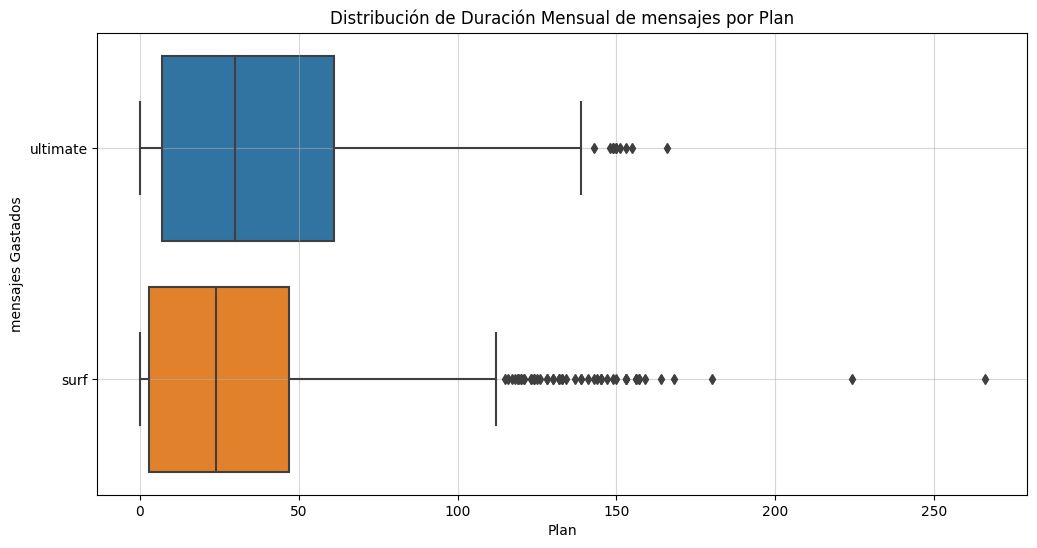

In [51]:
plt.figure(figsize=(12,6))
sns.boxplot(data=final_meg_merged, y='plan', x='msg_count')
plt.title('Distribución de Duración Mensual de mensajes por Plan')
plt.grid(True,alpha=0.5)
plt.xlabel('Plan')
plt.ylabel('mensajes Gastados')
plt.show()


Al revisar el uso de mensajes, notamos que los patrones a lo largo del año son muy similares en ambos planes. Sin embargo, el plan ultimate destaca ligeramente con un consumo más alto. Esto sugiere que los usuarios del plan surf prefieren otras funciones de su plan, como las llamadas, donde registran un uso más elevado que los del plan ultimate.

Observaciones clave:

Distribución: En este caso, encontramos una distribución con sesgo positivo (hacia la derecha).

Similitud estadística: Al igual que en el análisis anterior, la media y la varianza entre planes son muy próximas, lo que confirma una tendencia de comportamiento similar.

Valores atípicos (outliers): Es importante notar que, aunque ambos planes presentan valores atípicos, estos son mucho más frecuentes en el plan surf. Esto indica que, mientras la mayoría no usa los mensajes, hay un grupo reducido de usuarios que los utiliza de manera muy constante.

Uso marginal: Observamos una alta concentración de valores en 0. Esto indica que el servicio de mensajes no es una prioridad para la mayoría, independientemente del plan contratado; parece ser un servicio con baja relevancia frente a otras formas de comunicación digital.

### Internet

In [52]:

display(final_meg_merged.head(2))

int_per_month = final_meg_merged.groupby(['month','plan'])['gb_used'].mean().unstack()

print(int_per_month.describe())

,user_id,month,calls_made,minutes_spent,msg_count,mb_total,gb_used,plan,city,state,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month,usd_per_mb,total_revenue
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",GA,1000,30720,3000,70,7,0.01,0.01,30,0.006836,70.0
1,1001,8,27.0,182.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",WA,50,15360,500,20,10,0.03,0.03,15,0.009766,20.0


plan        surf   ultimate
count  12.000000  12.000000
mean   14.594808  16.346165
std     3.628348   2.991152
min     5.000000   7.250000
25%    13.229469  16.451977
50%    15.957816  17.064869
75%    16.877704  17.749003
max    18.238994  18.416667


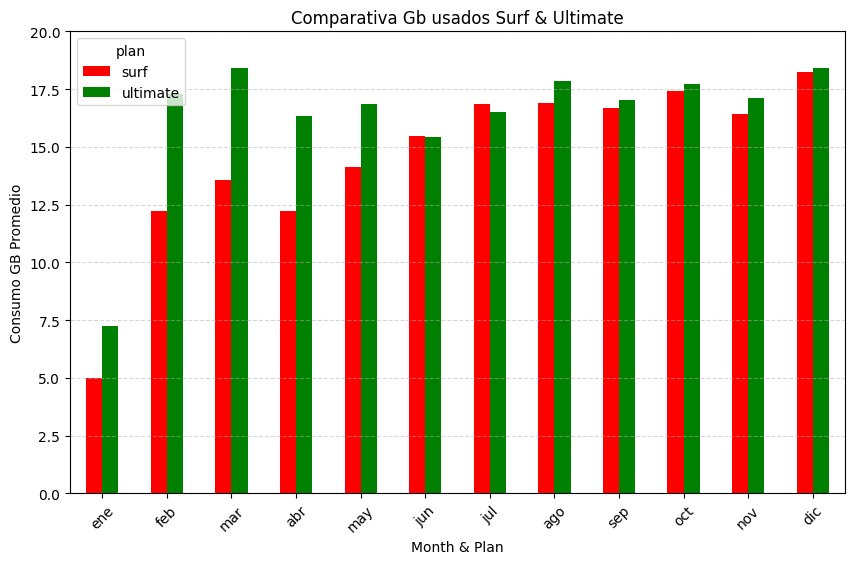

In [53]:
int_graph = int_per_month.plot(kind='bar',
                                        xlabel='Month & Plan', ylabel='Consumo GB Promedio'
                                        ,color=['red','green'], rot=45,
                                        legend=True,
                                        title='Comparativa Gb usados Surf & Ultimate',
                                        figsize=(10,6),
                                        ylim=(0,20)
                                        )
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(list(months.keys()),list(months.values()))

plt.show()

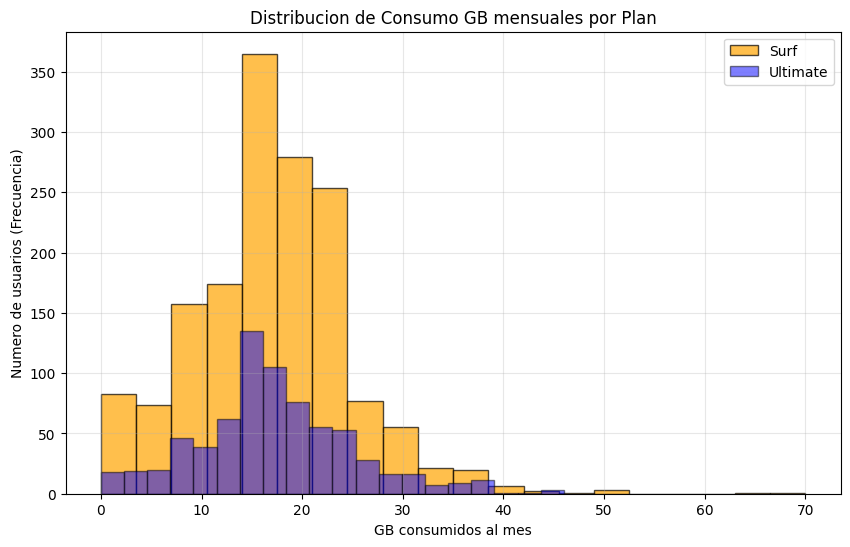


El número total de registros es: 2293
El número total de registros del plan 'surf' es: 1573, lo que equivale a un: 69 %
El número total de registros del plan 'ultimate' es: 720 lo que equivale a un: 31 %


In [54]:
surf_int = final_meg_merged[final_meg_merged['plan']=='surf']['gb_used']
ultimate_int = final_meg_merged[final_meg_merged['plan']=='ultimate']['gb_used']

plt.figure(figsize=(10,6))
plt.hist(surf_int, bins=20, alpha=0.7, label='Surf', color='orange', edgecolor='black')
plt.hist(ultimate_int, bins=20, alpha=0.5, label='Ultimate', color='blue',edgecolor='black')

plt.legend(loc='upper right')
plt.xlabel('GB consumidos al mes')
plt.ylabel('Numero de usuarios (Frecuencia)')
plt.title('Distribucion de Consumo GB mensuales por Plan')
plt.grid(True, alpha=0.3)
plt.show()

print()
print(f"El número total de registros es: {users_total}")
print(f"El número total de registros del plan 'surf' es: {surf_users}, lo que equivale a un: {((surf_users/users_total)*100):.0f} %")
print(f"El número total de registros del plan 'ultimate' es: {ultimate_users} lo que equivale a un: {((ultimate_users/users_total)*100):.0f} %")

In [55]:
surf_int_mean = df_surf['gb_used'].mean()
ultimate_int_mean = df_ultimate['gb_used'].mean()

surf_int_var = df_surf['gb_used'].var()
ultimate_int_var = df_ultimate['gb_used'].var()

surf_int_std = df_surf['gb_used'].std()
ultimate_int_std = df_ultimate['gb_used'].std()

print(f"Plan Surf - Media: {surf_int_mean:.2f}, Varianza: {surf_int_var:.2f}, Desviación estndar: {surf_int_std:.2f}")
print(f"Plan Ultimate - Media: {ultimate_int_mean:.2f}, Varianza: {ultimate_int_var:.2f}, Desviación estndar: {ultimate_int_std:.2f}")
print()
print("Plan Surf:")
print(f"Mínimo: {df_surf['gb_used'].min()}")
print(f"Máximo: {df_surf['gb_used'].max()}")
print("\nPlan Ultimate:")
print(f"Mínimo: {df_ultimate['gb_used'].min()}")
print(f"Máximo: {df_ultimate['gb_used'].max()}")

Plan Surf - Media: 16.67, Varianza: 61.58, Desviación estndar: 7.85
Plan Ultimate - Media: 17.31, Varianza: 58.83, Desviación estndar: 7.67

Plan Surf:
Mínimo: 0.0
Máximo: 70.0

Plan Ultimate:
Mínimo: 0.0
Máximo: 46.0


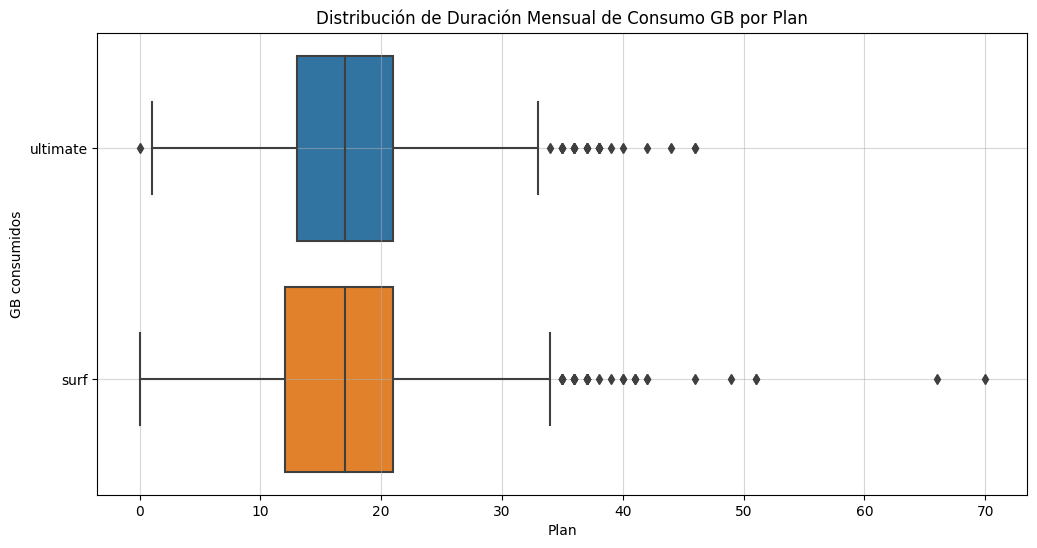

In [56]:
plt.figure(figsize=(12,6))
sns.boxplot(data=final_meg_merged, y='plan', x='gb_used')
plt.title('Distribución de Duración Mensual de Consumo GB por Plan')
plt.grid(True,alpha=0.5)
plt.xlabel('Plan')
plt.ylabel('GB consumidos')
plt.show()


Al analizar el consumo mensual y la distribución de los datos, observamos que, aunque existen diferencias en los límites de cada plan, el comportamiento general entre ambos no varía de forma drástica.

Comportamiento por plan:

Plan Ultimate: En general, los usuarios se mantienen dentro del límite de datos contratado. Aunque existen algunos valores atípicos (outliers), la mayoría de los usuarios no llega a agotar su cupo mensual.

Plan Surf: Aquí la dinámica es distinta. Muchos usuarios requieren más datos de los que incluye el plan, excediendo su límite con frecuencia. Al igual que en el caso anterior, encontramos valores atípicos que superan considerablemente el rango esperado, lo que sugiere un grupo de usuarios con un consumo intensivo.

Conclusiones:

Mientras que los usuarios del plan ultimate suelen estar bajo su límite, los del plan surf tienden a alcanzarlo y superarlo, especialmente durante la segunda mitad del año y en fechas festivas.

A pesar de que el plan ultimate registra un consumo promedio de datos mayor mes a mes, el plan surf destaca por ser el que genera más excedentes, lo cual refuerza la importancia de este plan como fuente de ingresos adicionales.



## Ingreso

In [57]:
display(final_meg_merged.head(2))

revenue_df = final_meg_merged.copy()
cols_to_bill = ['minutes_spent', 'msg_count', 'gb_used']
revenue_df[cols_to_bill] = revenue_df[cols_to_bill].fillna(0)

income_per_month = revenue_df.groupby(['month','plan'])['total_revenue'].mean().unstack()

print(income_per_month.describe())

,user_id,month,calls_made,minutes_spent,msg_count,mb_total,gb_used,plan,city,state,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,gb_per_month,usd_per_mb,total_revenue
0,1000,12,16.0,124.0,11.0,1901.47,2.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",GA,1000,30720,3000,70,7,0.01,0.01,30,0.006836,70.0
1,1001,8,27.0,182.0,30.0,6919.15,7.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",WA,50,15360,500,20,10,0.03,0.03,15,0.009766,20.0


plan        surf   ultimate
count  12.000000  12.000000
mean   51.401025  72.011068
std    14.698256   1.364068
min    20.000000  70.000000
25%    44.633628  71.409758
50%    53.640282  71.966594
75%    62.988330  72.894366
max    70.557044  74.666667


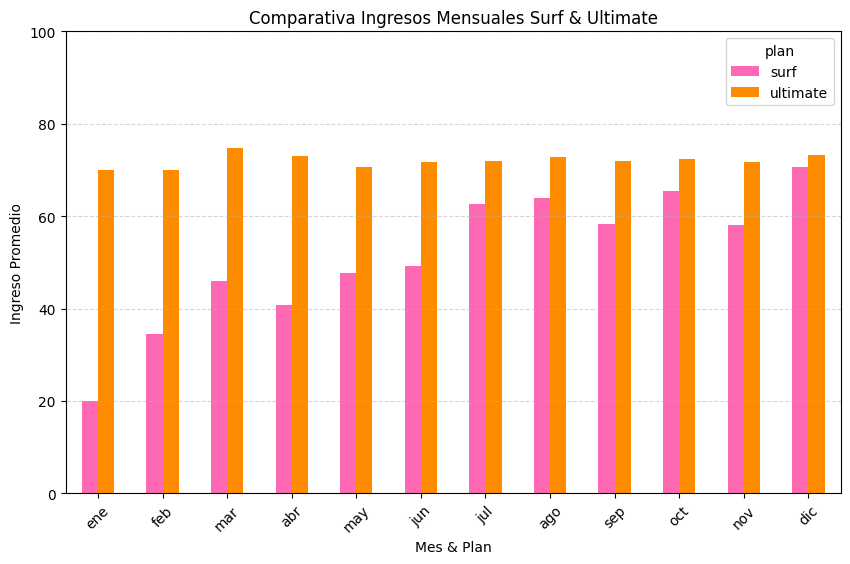

In [58]:
income_graph = income_per_month.plot(kind='bar',
                                        xlabel='Mes & Plan', ylabel='Ingreso Promedio'
                                        ,color=['hotpink','darkorange'], rot=45,
                                        legend=True,
                                        title='Comparativa Ingresos Mensuales Surf & Ultimate',
                                        figsize=(10,6),
                                        ylim=(0,100)
                                        )
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(list(months.keys()),list(months.values()))

plt.show()

In [59]:
surf_income = final_meg_merged[final_meg_merged['plan']=='surf']['total_revenue']
ultimate_income = final_meg_merged[final_meg_merged['plan']=='ultimate']['total_revenue']

max_surf = surf_income.max()
max_ultimate = ultimate_income.max()

print(f"Máximo Surf: ${max_surf:.2f}")
print(f"Máximo Ultimate: ${max_ultimate:.2f}")

Máximo Surf: $590.37
Máximo Ultimate: $182.00


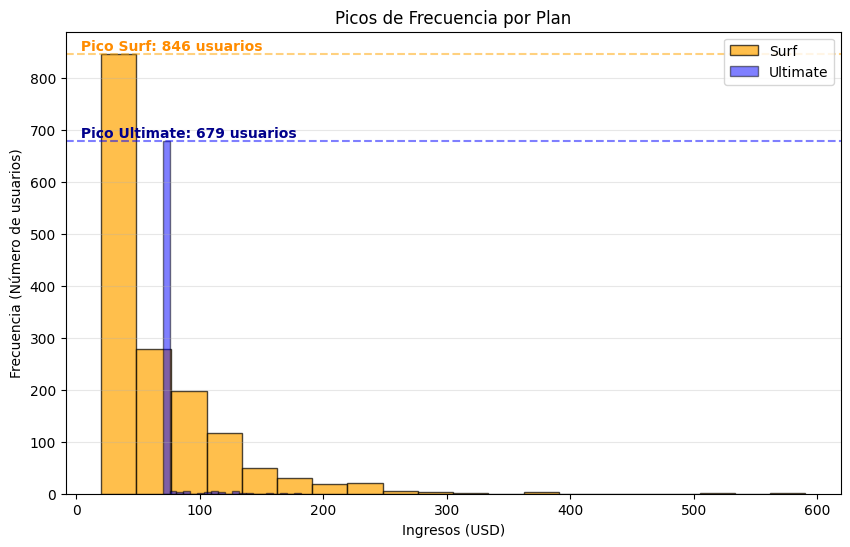


°El número total de registros es: 2293
°El número total de registros del plan 'surf' es: 1573, lo que equivale a un: 69 %
°El número total de registros del plan 'ultimate' es: 720 lo que equivale a un: 31 %

- De un total de 1573 registros Surf, 
846 Usuarios se mantien dentro de su limite de consumo. 
Lo que representa un 53.78% del ingreso total del plan Surf. 
Alrededor de $17020.00 USD

- De un Ingreso Total de $ 95491.18 USD con el Plan Surf

- De un total de 720 registros Ultimate, 
679 Usuarios se mantien dentro de su limite de consumo. 
Lo que representa un 94.31% del ingreso total del plan Ultimate. 
Alrededor de $47530.00 USD

- De un Ingreso Total de $ 52066.00 USD con el Plan Ultimate


In [60]:
surf_income = final_meg_merged[final_meg_merged['plan']=='surf']['total_revenue']
ultimate_income = final_meg_merged[final_meg_merged['plan']=='ultimate']['total_revenue']

plt.figure(figsize=(10,6))

# Guardamos el resultado del histograma en variables
# 'n' contiene las alturas (frecuencias) de cada barra
n_surf, bins_surf, _ = plt.hist(surf_income, bins=20, alpha=0.7, label='Surf', color='orange', edgecolor='black')
n_ultimate, bins_ultimate, _ = plt.hist(ultimate_income, bins=20, alpha=0.5, label='Ultimate', color='blue', edgecolor='black')

# Encontramos el valor máximo de las alturas
max_freq_surf = n_surf.max()
max_freq_ultimate = n_ultimate.max()

# Dibujamos una línea horizontal y colocamos un texto en el pico
plt.axhline(max_freq_surf, color='orange', linestyle='--', alpha=0.5)
plt.text(0, max_freq_surf, f' Pico Surf: {int(max_freq_surf)} usuarios', color='darkorange', fontweight='bold', va='bottom')

plt.axhline(max_freq_ultimate, color='blue', linestyle='--', alpha=0.5)
plt.text(0, max_freq_ultimate, f' Pico Ultimate: {int(max_freq_ultimate)} usuarios', color='darkblue', fontweight='bold', va='bottom')

plt.legend(loc='upper right')
plt.xlabel('Ingresos (USD)')
plt.ylabel('Frecuencia (Número de usuarios)')
plt.title('Picos de Frecuencia por Plan')
plt.grid(axis='y', alpha=0.3)
plt.show()

print()
print(f"°El número total de registros es: {users_total}")
print(f"°El número total de registros del plan 'surf' es: {surf_users}, lo que equivale a un: {((surf_users/users_total)*100):.0f} %")
print(f"°El número total de registros del plan 'ultimate' es: {ultimate_users} lo que equivale a un: {((ultimate_users/users_total)*100):.0f} %")
print(f"\n- De un total de {surf_users} registros Surf, \n{max_freq_surf.astype('int')} Usuarios se mantien dentro de su limite de consumo. \nLo que representa un {((max_freq_surf/surf_users)*100):.2f}% del ingreso total del plan Surf. \nAlrededor de ${(20*851):.2f} USD")
print(f"\n- De un Ingreso Total de $ {final_meg_merged[final_meg_merged['plan'] == 'surf']['total_revenue'].sum():.2f} USD con el Plan Surf")
print(f"\n- De un total de {ultimate_users} registros Ultimate, \n{max_freq_ultimate.astype('int')} Usuarios se mantien dentro de su limite de consumo. \nLo que representa un {((max_freq_ultimate/ultimate_users)*100):.2f}% del ingreso total del plan Ultimate. \nAlrededor de ${(70*679):.2f} USD")
print(f"\n- De un Ingreso Total de $ {final_meg_merged[final_meg_merged['plan'] == 'ultimate']['total_revenue'].sum():.2f} USD con el Plan Ultimate")

In [61]:
surf_income_mean = df_surf['total_revenue'].mean()
ultimate_income_mean = df_ultimate['total_revenue'].mean()

surf_income_var = df_surf['total_revenue'].var()
ultimate_income_var = df_ultimate['total_revenue'].var()

surf_income_std = df_surf['total_revenue'].std()
ultimate_income_std = df_ultimate['total_revenue'].std()

print(f"Plan Surf - Media: {surf_income_mean:.2f}, Varianza: {surf_income_var:.2f}, Desviación estndar: {surf_income_std:.2f}")
print(f"Plan Ultimate - Media: {ultimate_income_mean:.2f}, Varianza: {ultimate_income_var:.2f}, Desviación estndar: {ultimate_income_std:.2f}")
print()
print("Plan Surf:")
print(f"Mínimo: {df_surf['total_revenue'].min()}")
print(f"Máximo: {df_surf['total_revenue'].max()}")
print("\nPlan Ultimate:")
print(f"Mínimo: {df_ultimate['total_revenue'].min()}")
print(f"Máximo: {df_ultimate['total_revenue'].max()}")

Plan Surf - Media: 60.71, Varianza: 3067.84, Desviación estndar: 55.39
Plan Ultimate - Media: 72.31, Varianza: 129.85, Desviación estndar: 11.40

Plan Surf:
Mínimo: 20.0
Máximo: 590.37

Plan Ultimate:
Mínimo: 70.0
Máximo: 182.0


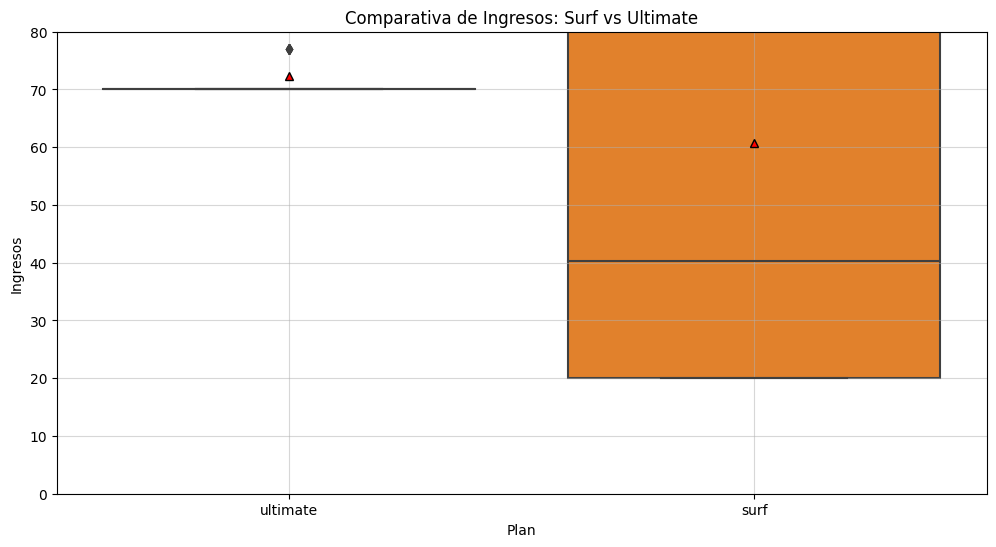

In [62]:

plt.figure(figsize=(12,6))
sns.boxplot(data=final_meg_merged, x='plan', y='total_revenue', showmeans=True, meanprops={"markerfacecolor":"red", "markeredgecolor":"black"})
plt.title('Comparativa de Ingresos: Surf vs Ultimate')
plt.grid(True,alpha=0.5)
plt.ylim(0,80)
plt.xlabel('Plan')
plt.ylabel('Ingresos')
plt.show()


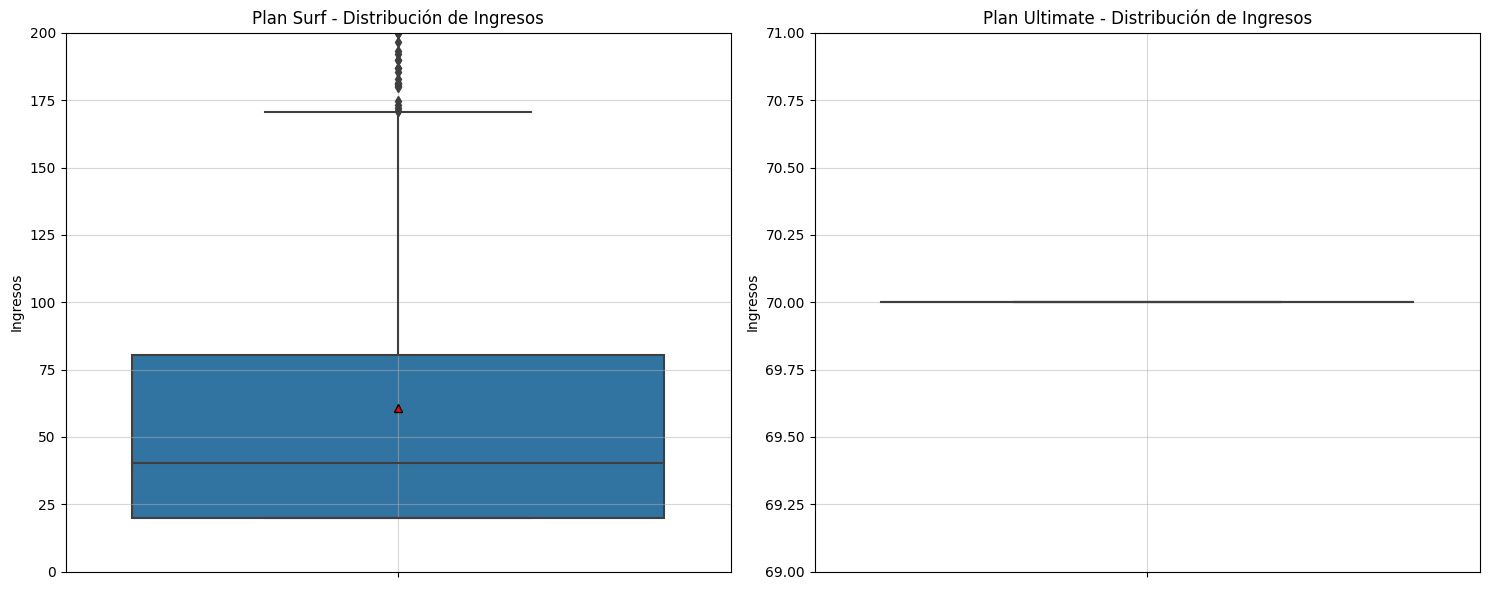

In [63]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

surf_data = final_meg_merged[final_meg_merged['plan'] == 'surf']
ultimate_data = final_meg_merged[final_meg_merged['plan'] == 'ultimate']

# Gráfico 1: Plan Surf
sns.boxplot(data=surf_data, y='total_revenue', ax=ax1, showmeans=True, 
            meanprops={"markerfacecolor":"red", "markeredgecolor":"black"})
ax1.set_title('Plan Surf - Distribución de Ingresos')
ax1.set_ylabel('Ingresos')
ax1.grid(True, alpha=0.5)
ax1.set_ylim(0, 200)

# Gráfico 2: Plan Ultimate
sns.boxplot(data=ultimate_data, y='total_revenue', ax=ax2, showmeans=True, 
            meanprops={"markerfacecolor":"red", "markeredgecolor":"black"})
ax2.set_title('Plan Ultimate - Distribución de Ingresos')
ax2.set_ylabel('Ingresos')
ax2.grid(True, alpha=0.5)
ax2.set_ylim(69,71)

plt.tight_layout()
plt.show()

**Cálculo de ingresos mensuales por usuario**

Para determinar el ingreso total, calculamos los costos excedentes en llamadas, mensajes y tráfico de internet, sumándolos al costo base de cada plan. Utilizamos la función `np.maximum(0, diferencia)` para garantizar que, si el consumo está dentro del límite, el costo adicional sea `0`.

**Cálculo de excedentes:**

- Minutos: Calculamos la diferencia entre los minutos consumidos y los incluidos, multiplicando el resultado positivo por `usd_per_minute`.

- Mensajes: Obtenemos el costo extra multiplicando el exceso de mensajes por `usd_per_message`.

- Datos (GB): Calculamos el costo por GB excedente multiplicando por `usd_per_gb`.

- Ingreso total (`total_revenue`):
Consolidamos el costo mensual base del plan más los costos variables calculados previamente.

Codigo:
`final_meg_merged['total_revenue'] = (final_meg_merged['usd_monthly_pay'] + mins_cost + msg_cost + gb_cost)`

Validación de resultados:

Finalmente, extraemos un resumen con las columnas user_id, month, plan y total_revenue. Ejecutamos `isna().sum()` para confirmar la integridad de los datos; la ausencia de valores nulos es el indicador clave de que el cálculo y la consolidación de unidades se realizaron exitosamente.

In [64]:
# Sumamos el total de cada columna de costo que calculamos antes
total_mins_usd = mins_cost.sum()
total_msgs_usd = msg_cost.sum()
total_gb_usd = gb_cost.sum()
total_base_usd = final_meg_merged['usd_monthly_pay'].sum()

print("--- DESGLOSE DE INGRESOS TOTALES (MUESTRA COMPLETA) ---")
print(f"Ingresos por rentas básicas:  ${total_base_usd:,.2f}")
print(f"Ingresos por exceso de GB:    ${total_gb_usd:,.2f}")
print(f"Ingresos por exceso de Min:    ${total_mins_usd:,.2f}")
print(f"Ingresos por exceso de SMS:    ${total_msgs_usd:,.2f}")
print("-" * 40)
print(f"INGRESO TOTAL NETO:           ${(total_base_usd + total_gb_usd + total_mins_usd + total_msgs_usd):,.2f}")


--- DESGLOSE DE INGRESOS TOTALES (MUESTRA COMPLETA) ---
Ingresos por rentas básicas:  $81,860.00
Ingresos por exceso de GB:    $62,466.00
Ingresos por exceso de Min:    $2,900.25
Ingresos por exceso de SMS:    $330.93
----------------------------------------
INGRESO TOTAL NETO:           $147,557.18


Encontramos una diferencia importante en la estructura de ingresos de cada plan. Cada uno tiene un rol distinto dentro del mercado:

Plan Ultimate: Estabilidad Premium
Este plan se caracteriza por ofrecer un margen de consumo amplio que la mayoría de los usuarios no llega a agotar.

Comportamiento: Son usuarios muy activos en llamadas, pero con poco uso de mensajes. Su consumo de internet es alto, pero generalmente se mantiene dentro de los límites establecidos.

Perfil: Al ser una opción de mayor costo, es menos accesible para el mercado masivo, pero compensa con una consistencia financiera. Sus ingresos son muy estables mes a mes, aunque es probable que el precio sea una barrera de entrada para muchos.

Oportunidad: Dado que el plan ultimate ya tiene un 94% de sus usuarios manteniéndose dentro de sus límites, la oportunidad de crecimiento aquí no está en los excedentes, sino en estrategias de fidelización para mantener esa base estable y evitar la migración a otras operadoras.

Plan Surf: Volumen y Excedentes
Es el preferido por el mercado, representando más de la mitad de nuestra base de usuarios. Su precio, significativamente menor (hasta 3 veces menos que el ultimate), es el factor decisivo al contratar.

Rentabilidad por excedentes: Al ser el plan más económico, los límites son más ajustados. Esto provoca que muchos usuarios excedan sus límites frecuentemente, generando cobros adicionales.

Datos de ingresos: Del total de ingresos del plan surf ($94,902.13), observamos una dinámica interesante:

Solo el 54.10% de los registros se mantienen dentro de sus límites, sumando $17,020.00.

La diferencia restante, $77,882.13, proviene exclusivamente de los cargos por excedentes.

Conclusión del comparativo
Mientras que el plan ultimate es consistente y rentable por su tarifa base, el plan surf basa su éxito en el volumen de usuarios y en la recurrencia de los cobros por excedentes. En resumen: el ultimate aporta estabilidad, mientras que el surf es nuestro motor de crecimiento y rentabilidad variable.


## Prueba las hipótesis estadísticas

Para esta prueba usaremos un hipotesis de 2 colas para verificar si existe diferenecia entre las 2 muestras ya que la intencion es unicamente determinar si exisste diferencia entre ambas.

Para ello usaremos las siguientes Hipotesis:

H₀ = Hipoteesis Nula = μ_Ultimate = μ_Surf

H₁ = Hipotesis Alternativa = μ_Ultimate ≠ μ_Surf

- H₀ = Los ingresos de los planes "Surf" y "Ultimate" no se diferencian entre si.
- H₁ = los ingresos de los planes "Surf" y "Ultimate" muestran una difrencia entre uno a otro.
  
Estableceremos Un Valor alpha de 5% para esta comprobación.



In [65]:
# Prueba las hipótesis


alpha = 0.05

results_income = st.ttest_ind(surf_income,ultimate_income, equal_var=False)# realiza la prueba t


print('valor p: ',results_income.pvalue)# extrae el valor p de los resultados de la prueba

if (results_income.pvalue < alpha):# compara el valor p con el umbral alpha
    print('Rechazamos la hipótesis nula')
else:
    print("No podemos rechazar la hipótesis nula")





valor p:  3.1703905481135734e-15
Rechazamos la hipótesis nula


Respuesta:

Se agrego el parametro `equal_var=False` para aplicar la prueba de Welch ya que las varianzas son muy dispares de las muestras de datos.

Dado el resultado obtenido es un numero muy pequeño se determina que no tenemos suficientes probabilidades de que las muestras sean iguales, por lo que existe una diferencia como se muestra en el histograma anterior. aunque la media se algo cercana de ambas muestras. las varianzas son muy desiguales por lo que la prueba de 2 colas es la mejoir opcion para la prueba de hipotesis.

## ¿El ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.?


Del mismo modo que la prueba anterior usaremos una prueba de 2 colas ya que el fin s dterminar si existen diferencias entre el ingreso de los usuarios de una sona determinada contra el ingreso de las demas regiones.

H₀= No existen diferencias entre los ingresos promedio de los usuarios de NY-NJ a otras regiones.

H₁ = Existen diferencias entre los ingresos promedio de los usuarios de NY-NJ contra las otras regiones.

H₀: μ_NY-NJ = μ_otras_regiones (Los ingresos promedio son iguales)

H₁: μ_NY-NJ ≠ μ_otras_regiones (Los ingresos promedio son diferentes)

Se establece un valor Alpha de 0.05 para esta prueba. (estandar)

In [68]:
# Prueba las hipótesis

print('Los Valores almacenados en nuestro dataFrame para los estados de los usuarios son:')
print()
print(final_meg_merged['state'].unique()) # Verificamos los valores de los estados almacenados.

ny_nj_users = final_meg_merged[final_meg_merged['state'].isin(['NY-NJ-PA', 'NY'])] # filtramos unicamente los estados que nos interesan (NY, NY-NJ-PA) que son las regiones de interes para esta hipotesis.
other_regions_users = final_meg_merged[~final_meg_merged['state'].isin(['NY-NJ-PA', 'NY'])] # usamos el mismo codigo solo usando el simbolo de negacion al inicio para obtener el filtro a la inversa. 


ny_nj_users_income = ny_nj_users['total_revenue'] # filtrado por estados obtenemos unicamente la muestra de los ingresos por estos 2 estados
other_reg_user_inc = other_regions_users['total_revenue'] # obtenemos los oingresos de todas las demas regiones.

ny_nj_users_data_mean = ny_nj_users_income.describe()['mean']
other_reg_user_inc_mean = other_reg_user_inc.describe()['mean']

ny_nj_users_data_var = ny_nj_users_income.var()
other_reg_user_inc_var = other_reg_user_inc.var()
print()
print(f"La media de los registros de NY-NJ es de: {ny_nj_users_data_mean:.2f} y la varianza es de: {ny_nj_users_data_var:.2f}")
print()
print(f"La media de los registros del resto de los estados es de: {other_reg_user_inc_mean:.2f} y la varianza es de: {other_reg_user_inc_var:.2f}")
print()
print("NY-NJ - Min:", ny_nj_users_income.min(), "Max:", ny_nj_users_income.max())
print("Otras regiones - Min:", other_reg_user_inc.min(), "Max:", other_reg_user_inc.max())

print(f"Registros NY-NJ: {len(ny_nj_users_income)}")
print(f"Registros otras regiones: {len(other_reg_user_inc)}")


alpha_2= 0.05 # Establecemos en indice de confianza en el estandar de 5%

reg_results= st.ttest_ind(ny_nj_users_income,other_reg_user_inc)
print()
print ('Valor p: ', reg_results.pvalue)
if (reg_results.pvalue < alpha_2):
   print('Rechazamos la hipótesis nula')
else:
    print("No podemos rechazar la hipótesis nula")


Los Valores almacenados en nuestro dataFrame para los estados de los usuarios son:

['GA' 'WA' 'NV' 'OK' 'TX' 'CA' 'MI' 'FL' 'OH' 'IL-IN-WI' 'TN' 'NY-NJ-PA'
 'PA' 'DC-VA-MD-WV' 'IN' 'NE-IA' 'PA-NJ-DE-MD' 'AL' 'NC-SC' 'CO' 'NM'
 'MA-NH' 'AZ' 'OR-WA' 'OH-KY-IN' 'SC' 'NY' 'TN-MS-AR' 'KY-IN' 'RI-MA' 'HI'
 'CT' 'LA' 'VA-NC' 'MD' 'WI' 'VA' 'MO-IL' 'MN-WI' 'MO-KS' 'NC' 'UT']

La media de los registros de NY-NJ es de: 60.90 y la varianza es de: 1996.92

La media de los registros del resto de los estados es de: 65.09 y la varianza es de: 2209.93

NY-NJ - Min: 20.0 Max: 280.0
Otras regiones - Min: 20.0 Max: 590.37
Registros NY-NJ: 406
Registros otras regiones: 1887

Valor p:  0.10065559377767899
No podemos rechazar la hipótesis nula


## Conclusión general

Después de analizar los datos y ver cómo se comportan los usuarios, esto es lo que encontré:

**1. Lo que asumimos al inicio**

Para que los números cuadraran, tuvimos que tomar algunas decisiones:

Los espacios en blanco son ceros: Si un usuario no tenía registros de llamadas o internet en un mes, asumimos que no usó el servicio, no que fue un error. Así pudimos sumar todo sin problemas.

Todo se calcula por mes: Asumimos que los cobros se cortan al final de cada mes y los excedentes se miden mes a mes de forma independiente.

La muestra nos sirve: Damos por hecho que los usuarios de esta muestra se parecen a todos los demás clientes de la compañía.

**2. Decisiones que tomé en el camino**

Mejor organización: Usé unstack() para que los meses quedaran como filas y los planes como columnas; así es mucho más fácil comparar el Surf contra el Ultimate en las gráficas.

Limpieza primero: Apliqué fillna(0) antes de calcular el dinero total. Si no, hubiera perdido más de 500 filas de datos que eran importantes.

Más que solo promedios: No me quedé solo con el promedio, porque a veces engaña. Usé histogramas para ver la "forma" del consumo y boxplots para identificar a esos usuarios que gastan muchísimo más que el resto (los famosos outliers).

Prueba estadística: Usé una prueba T con un nivel de confianza del 5% para estar seguro de que las diferencias de dinero entre planes eran reales y no pura suerte.

**3. Lo más importante que encontré**

El plan Surf es una mina de oro: Aunque es barato, mucha gente se pasa de su límite, sobre todo en internet. Algunos usuarios de Surf terminan pagando tanto o más que los del Ultimate.

El plan Ultimate es pura estabilidad: Los que pagan este plan casi nunca se pasan de sus límites. La empresa ya sabe cuánto va a ganar con ellos, pero no generan dinero extra por penalizaciones.

El negocio está en los datos (GB): Comparando llamadas, mensajes e internet, me di cuenta de que lo que realmente infla las facturas son los datos. Las llamadas casi siempre se mantienen en niveles normales.

La ubicación no importa: Me sorprendió ver que la gente de Nueva York o Nueva Jersey gasta prácticamente lo mismo que los de otras zonas. No hay un "comportamiento regional" especial.

**4. Mi sugerencia**

Como hay muchos usuarios en el plan Surf que se la pasan pagando excedentes, creo que a la empresa le convendría crear un plan intermedio. Así, los usuarios que se pasan seguido de su límite de internet podrían contratar este nuevo plan en lugar de sentirse "castigados" con tantos cobros extra.

